<a href="https://www.kaggle.com/code/eymenakb/electric-vehicle?scriptVersionId=347076267" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Welcome
### This is a basic script using xgboost and optuna for Predicting Electric Vehicle Purchases

competition: [comptetition](https://www.kaggle.com/competitions/playground-series-s6e9)
kaggle: [kaggle](https://www.kaggle.com/eymenakb)
github: [github](https://github.com/EymenAkb)

In [1]:
!pip install optuna optuna-integration scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 1.1 MB/s eta 0:00:00


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e9/train.csv
/kaggle/input/competitions/playground-series-s6e9/test.csv


## Importing the neccesarry libraries

#### Descriptions and Libraries:

xgboost: A library for gradient boosted machine Learning.

optuna: Machine Learning optimization library.

matplotlib.pyplot: Visualization and plotting library.
seaborn: Visualization and plotting library.

math: native python mathematical work library.

sci-kit_learn (sklearn): Optimization, pipelines, composing, preprocessing, folding and every preprocess step handler for ML.

In [3]:
import xgboost as xgb
from xgboost import XGBClassifier

import optuna

import matplotlib.pyplot as plt
import seaborn as sns

import math

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import StratifiedKFold

In [4]:
#plt.style.available # useful for checking the available plt styles.
plt.style.use("seaborn-v0_8")

## Mini utility methods

### Descriptions:

num_cols: used for selecting numerical_columns, DRY (Don't repeat yourself) code.
cat_cols: used for selecting categorical_columns, DRY (Don't repeat yourself) code.

feature_all_charge_stations: feature code, new column that sums up charging stations near home and nearh work.
feature_km_by_car: feature code, new column for calculating the km usage per car.

In [5]:
def num_cols(data) -> list:
    return data.select_dtypes(include=np.number).columns.tolist()

def cat_cols(data) -> list:
    return data.select_dtypes(exclude=np.number).columns.tolist()

def feature_all_charge_stations(data, return_columns:bool=False, copy:bool=False) -> pd.DataFrame | tuple[pd.DataFrame, list, list]:
    if copy:
        data = data.copy(True)
    data["all_charge_stations"] = data["Charging_Stations_Near_Home"] + data["Charging_Stations_Near_Work"]
    if return_columns:
        numerical_columns = num_cols(data)
        categorical_columns = cat_cols(data)
        return data, numerical_columns, categorical_columns
    return data

def feature_km_by_car(data, return_columns:bool=False, copy:bool=False):
    if copy:
        data = data.copy(True)
    data["km_by_car"] = data["Daily_Commute_km"] / data["Number_of_Cars_Owned"].replace(0, np.nan)
    if return_columns:
        numerical_columns = num_cols(data)
        categorical_columns = cat_cols(data)
        return data, numerical_columns, categorical_columns
    return data

# Loading the data
Handling feature engineering and other variables, removing the target from columns and calculating unique count of cateogrical columns (used for finding which encoding method is useful)

In [6]:
train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv", index_col=0)
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv", index_col=0)

feature_all_charge_stations(train_df)
feature_km_by_car(train_df)
feature_all_charge_stations(test_df)
feature_km_by_car(test_df)

numerical_columns = num_cols(train_df)
categorical_columns = cat_cols(train_df)
target = "Will_Buy_EV"

if target in numerical_columns:
    numerical_columns.remove(target)
    
if target in categorical_columns:
    categorical_columns.remove(target)
    
total_cat = 0
total_cat = train_df[categorical_columns].nunique().sum()

print(f"Total Categorical unique values:\n{total_cat - 2}\n")

train_df.info()

Total Categorical unique values:
15

<class 'pandas.core.frame.DataFrame'>
Index: 668665 entries, 0 to 668664
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Age                          668665 non-null  int64  
 1   Annual_Income_USD            668665 non-null  float64
 2   Daily_Commute_km             668665 non-null  float64
 3   Number_of_Cars_Owned         668665 non-null  int64  
 4   Charging_Stations_Near_Home  668665 non-null  int64  
 5   Charging_Stations_Near_Work  668665 non-null  int64  
 6   Environmental_Concern_Level  668665 non-null  float64
 7   Gender                       668665 non-null  object 
 8   City_Type                    668665 non-null  object 
 9   Current_Car_Type             668665 non-null  object 
 10  Home_Charging_Possible       668665 non-null  object 
 11  Subsidy_Available            668665 non-null  object 
 12  Range_Anxiety_Level       

## Plotting the data

Plotting the categorical_columns using barplot.
Plotting the numerical_columns using histplot, checking the correlation between numerical values using heatmap.

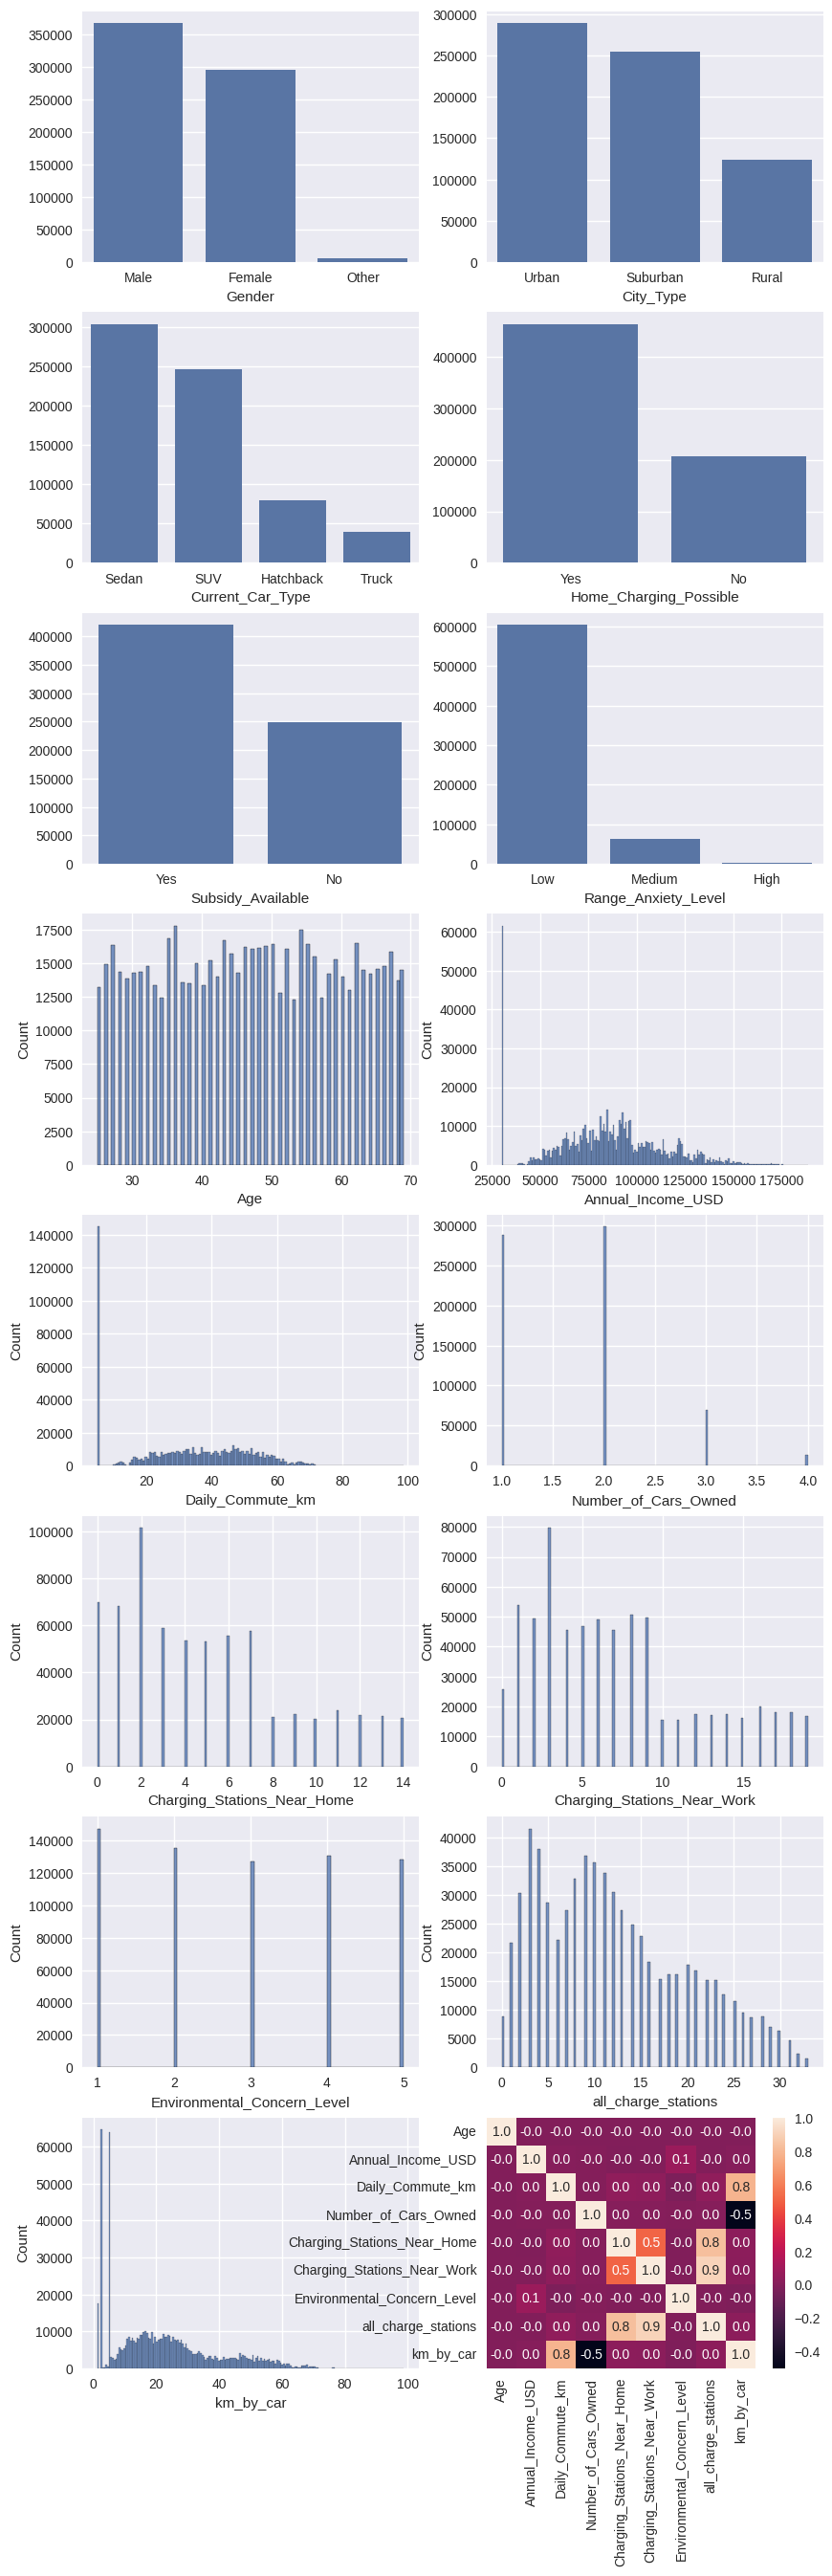

In [7]:
row_num = math.ceil((len(numerical_columns) + len(categorical_columns) + 1) / 2)
fig, ax = plt.subplots(nrows=row_num, ncols=2, figsize=(10, row_num * 4), squeeze=False)
axes_flat = ax.ravel()

for i, column in enumerate(categorical_columns):
    counts = train_df[column].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes_flat[i])

for j, column in enumerate(numerical_columns):
    index_for_ax = len(categorical_columns) + j
    sns.histplot(train_df[column], ax=axes_flat[index_for_ax])

sns.heatmap(train_df[numerical_columns].corr(),annot=True, fmt=".1f")

plt.show()

# Preprocessing

Setting up the preprocessor.

In [8]:
preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numerical_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns)
])

le = LabelEncoder()
x = train_df[numerical_columns + categorical_columns]
y = le.fit_transform(train_df[target])

x_transformed = preprocessor.fit_transform(x, y)

dtrain = xgb.DMatrix(x_transformed, label=y, missing=np.nan)

## Optimization / Optuna Trial

### Setting up a function (objective) to find optimal values

Using StratifiedKFold for cross validation.
Using PruningCallback for callbacks.

In [9]:
def objective(trial):
    params = {
        "objective": "binary:logistic",
        "device": "cuda",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    skf = StratifiedKFold(shuffle=True)
    pruning_callback = (optuna.integration.XGBoostPruningCallback(trial, "test-logloss"))
    folds = list(skf.split(x_transformed, y))

    try:
        cv = xgb.cv(params=params, dtrain=dtrain, num_boost_round=1500, folds=folds,
            early_stopping_rounds=50, callbacks=[pruning_callback], verbose_eval=False)

        metric_col = 'test-logloss-mean'

        best_iteration = cv[metric_col].idxmin()

        optimal_n_estimators = (best_iteration + 1)

        trial.set_user_attr("optimal_n_estimators",optimal_n_estimators)

        return cv.loc[best_iteration, metric_col]

    except optuna.exceptions.TrialPruned:
        raise

### Creating the study

starting the optimization

In [10]:
study = optuna.create_study(direction='minimize',sampler=optuna.samplers.TPESampler(multivariate=True))

study.optimize(objective, n_trials=30)

/tmp/ipykernel_23/2353526148.py:1: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  study = optuna.create_study(direction='minimize',sampler=optuna.samplers.TPESampler(multivariate=True))
[I 2026-09-03 18:55:03,179] A new study created in memory with name: no-name-7b9a4ede-cc56-4026-bd3a-f3ed038d7e98
/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.xgboost` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.xgboost` instead.
  return _bootstrap._gcd_import(name[level:], package, level)
[I 2026-09-03 18:55:19,698] Trial 0 finished with value: 0.22633690019057767 and parameters: {'learning_rate': 0.10679471200358247, 'max_depth': 3, 'subsample': 0.8680920980077017, 'colsample_bytree': 0.9053389099745679, 'min_child_weight': 15, 'gamma': 1.932488993628751e-06, 'reg_alpha': 0.000239329382825

## Fetching the optimal parameters

In [11]:
best_trial = study.best_trial

best_params = best_trial.params.copy()

best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'device': 'cuda',
    'tree_method': 'hist',
    'n_estimators': best_trial.user_attrs['optimal_n_estimators']})

# Setting up the final model.

Using the best parameters setting up the final pipeline.

In [12]:
final_model = XGBClassifier(
    **best_params
)

final_pipeline = Pipeline([
    ("preprocess",preprocessor),
    ("model",final_model)
])

## Fitting the final model on the Data

In [13]:
final_pipeline.fit(x, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age', 'Annual_Income_USD',
                                                   'Daily_Commute_km',
                                                   'Number_of_Cars_Owned',
                                                   'Charging_Stations_Near_Home',
                                                   'Charging_Stations_Near_Work',
                                                   'Environmental_Concern_Level',
                                                   'all_charge_stations',
                                                   'km_by_car']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gend...
                               gamma=1.932488993628751e-06, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.10679471200358247, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=7, max_depth=3, max_leaves=None,
                               min_child_weight=15, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=846, n_jobs=None,
                               num_parallel_tree=None, ...))])

# Predicting the submissions

Using the fitted final model predicting the results.

In [14]:
x_test = test_df[numerical_columns + categorical_columns]

numeric_predictions = final_pipeline.predict_proba(x_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [18:57:16] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


## Saving the results

Saving the results as submission.csv for submitting to the competition.

In [15]:
results = pd.DataFrame(
    numeric_predictions,
    index=x_test.index,
    columns=[target]
)

print(results[target].value_counts())

results.to_csv("submission.csv")

print(results.info())

Will_Buy_EV
0.011797    3
0.022355    3
0.000160    3
0.000154    3
0.002983    3
           ..
0.629611    1
0.468841    1
0.044001    1
0.677659    1
0.000903    1
Name: count, Length: 284934, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 286571 entries, 668665 to 955235
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Will_Buy_EV  286571 non-null  float32
dtypes: float32(1)
memory usage: 3.3 MB
None


# Feature Importances

Checking the feature importances for feature modifications.

In [16]:
encoded_cat_names = list(final_pipeline["preprocess"].transformers_[1][1].get_feature_names_out(categorical_columns))
feature_names = numerical_columns + encoded_cat_names

importances = final_pipeline["model"].feature_importances_

print("\n--- Feature Importances ---")
for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp:.4f}")


--- Feature Importances ---
Age: 0.0014
Annual_Income_USD: 0.0135
Daily_Commute_km: 0.0018
Number_of_Cars_Owned: 0.0007
Charging_Stations_Near_Home: 0.0011
Charging_Stations_Near_Work: 0.0007
Environmental_Concern_Level: 0.3097
all_charge_stations: 0.0006
km_by_car: 0.0007
Gender_Female: 0.0006
Gender_Male: 0.0007
Gender_Other: 0.0005
City_Type_Rural: 0.0010
City_Type_Suburban: 0.0010
City_Type_Urban: 0.0010
Current_Car_Type_Hatchback: 0.0009
Current_Car_Type_SUV: 0.0007
Current_Car_Type_Sedan: 0.0006
Current_Car_Type_Truck: 0.0010
Home_Charging_Possible_No: 0.0036
Home_Charging_Possible_Yes: 0.0111
Subsidy_Available_No: 0.4635
Subsidy_Available_Yes: 0.1053
Range_Anxiety_Level_High: 0.0054
Range_Anxiety_Level_Low: 0.0535
Range_Anxiety_Level_Medium: 0.0195


# This is it

The whole process of xgboost with optuna is given above, i hope you find it useful. Do not forget to upvote, for any questions and problems comment section is always up.

competition: [comptetition](https://www.kaggle.com/competitions/playground-series-s6e9)
kaggle: [kaggle](https://www.kaggle.com/eymenakb)
github: [github](https://github.com/EymenAkb)